In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict, Optional
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset

/Users/milesmarkey/projects/playground/sae_trainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

from sae_trainer.dataset_utils import make_collate_fn, TextDataset, get_data_loaders
from sae_trainer.train_utils import train_sae
from sae_trainer.eval_utils import evaluate_sae, visualize_sae
from sae_trainer.model_utils import SparseAutoencoder

In [ ]:
class ActivationCollector:
    """
    Collects activations from selected GPT-2 layers:
      - residual_out: output of decoder layer (hidden_states)
      - mlp_down_out: output of layer.mlp.c_proj (down projection)
    """
    def __init__(
        self,
        model: torch.nn.Module,
        layer_ids: List[int],
        capture_residual: bool = True,
        capture_mlp_down: bool = False,
        to_cpu: bool = True,
        dtype: torch.dtype = torch.float32,
    ):
        self.model = model
        self.layer_ids = layer_ids
        self.capture_residual = capture_residual
        self.capture_mlp_down = capture_mlp_down
        self.to_cpu = to_cpu
        self.dtype = dtype

        self.hooks = []
        self.buffer: Dict[str, Dict[int, torch.Tensor]] = {
            "residual_out": {},
            "mlp_down_out": {},
        }

    def _clear_batch_buffer(self):
        self.buffer["residual_out"].clear()
        self.buffer["mlp_down_out"].clear()

    @staticmethod
    def _hidden_from_output(output):
        # Some HF modules return tuple; hidden_states is first item
        return output[0] if isinstance(output, tuple) else output

    def _make_block_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            hs = self._hidden_from_output(output)
            t = hs.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["residual_out"][layer_idx] = t
        return hook

    def _make_mlp_down_hook(self, layer_idx: int):
        def hook(module, inputs, output):
            t = output.detach().to(self.dtype)
            if self.to_cpu:
                t = t.cpu()
            self.buffer["mlp_down_out"][layer_idx] = t
        return hook

    def register(self):
        self.remove()
        for i in self.layer_ids:
            layer = self.model.transformer.h[i]  # GPT-2: transformer.h[i]
            if self.capture_residual:
                self.hooks.append(layer.register_forward_hook(self._make_block_hook(i)))
            if self.capture_mlp_down:
                self.hooks.append(layer.mlp.c_proj.register_forward_hook(self._make_mlp_down_hook(i)))

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def collect_batch(self, model_inputs: Dict[str, torch.Tensor], model: Optional[torch.nn.Module] = None):
        """
        Runs one forward pass and returns flattened activations per layer:
          out[name][layer] -> [batch*seq, d_model]
        """
        if model is None:
            model = self.model

        self._clear_batch_buffer()
        with torch.no_grad():
            _ = model(**model_inputs)

        out = {"residual_out": {}, "mlp_down_out": {}}
        for name in out.keys():
            for layer_idx, x in self.buffer[name].items():
                # [B, S, D] -> [B*S, D]
                out[name][layer_idx] = x.reshape(-1, x.shape[-1])
        return out


In [ ]:
# --- Setup model/tokenizer ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2"  # GPT-2 small: 12 layers, d_model=768

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()


In [6]:
# --- Example text corpus ---
#texts = [
#    "The Eiffel Tower is in Paris.",
#    "A sparse autoencoder can discover interpretable features.",
#    "Neural networks represent concepts across many layers.",
#    "Attention heads may specialize in different linguistic patterns.",
#    "Residual stream activations are useful for mechanistic interpretability.",
#] * 200  # repeat just for demo

#dataset = TextDataset(texts)
texts = []
ds = load_dataset("wikitext", "wikitext-103-raw-v1", split="train", streaming=True)

#ds = ds.shuffle(seed=42)
#ds = ds.with_format("torch")
for row in ds:
    texts.append(row["text"])
dataset = TextDataset(texts)
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=make_collate_fn(tokenizer, max_length=128),
)

In [ ]:
# --- Register collector ---
# GPT-2 small has 12 layers (0-11); sample early, mid, late, and final
target_layers = [3, 6, 9, 11]
collector = ActivationCollector(
    model=model,
    layer_ids=target_layers,
    capture_residual=True,
    capture_mlp_down=False,   # set True if you want both
    to_cpu=True,
    dtype=torch.float32,
)
collector.register()


In [8]:
# --- Dataloader loop to accumulate activations ---
# Stores per-layer chunks, then concatenates at end.
accum = {"residual_out": {i: [] for i in target_layers},
         "mlp_down_out": {i: [] for i in target_layers}}

max_batches = 50  # increase for more data
for step, batch in enumerate(loader):
    if step >= max_batches:
        break

    batch = {k: v.to(device) for k, v in batch.items()}
    acts = collector.collect_batch(batch)

    # Optional: remove pad tokens before append
    # (for now we keep all tokens; filtering can be done later)

    for name in ["residual_out", "mlp_down_out"]:
        for i, x in acts[name].items():
            accum[name][i].append(x)

# concat
for name in ["residual_out", "mlp_down_out"]:
    for i in target_layers:
        if len(accum[name][i]) > 0:
            accum[name][i] = torch.cat(accum[name][i], dim=0)
        else:
            accum[name][i] = None

collector.remove()

for i in target_layers:
    x = accum["residual_out"][i]
    print(f"Layer {i} residual:", None if x is None else tuple(x.shape))

Layer 12 residual: (36864, 896)
Layer 16 residual: (36864, 896)
Layer 20 residual: (36864, 896)
Layer 23 residual: (36864, 896)


In [9]:
# Things to try:

# Decoder column unit norm
# Top-k forward (k~16-32)
# KL to target neuron firing rate

In [9]:
# 0.005 - 0.05
mass_frac_threshold=0.001

# Working combos:
# expansion=8, mass_frac_threshold=0.001
# expansion=16, mass_frac_threshold=0.0005

In [10]:
def training_wrapper(accum, layer_idx, device, mass_frac_threshold, save_filename=None):

    train_loader, val_loader, d_in = get_data_loaders(accum, layer_idx)
    # ---- Model + optimizer ----
    expansion = 8               # 4-16 are common starting points
    d_latent = d_in * expansion # d_in = 3584, so this should be in ~[14k, 60k] (14336-57344)

    sae = SparseAutoencoder(d_in=d_in, d_latent=d_latent).to(device)
    opt = torch.optim.AdamW(sae.parameters(), lr=3e-4, weight_decay=1e-4)

    # Sparsity strength: tune this. Start small.
    lambda_l1 = 1e-2

    # Optional: LR scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

    sae, history = train_sae(
        sae, 
        train_loader, 
        val_loader, 
        opt, 
        scheduler, 
        device, 
        lambda_l1=lambda_l1, 
        mass_frac_threshold=mass_frac_threshold,
        lambda_kl=1e-3,           # tune in log space, e.g. 1e-4 … 1e-2
        target_firing_rate=0.02,  # desired ~soft firing mass per latent
        )

    if save_filename:
        # ---- Save checkpoint ----
        ckpt = {
            "model_state": sae.state_dict(),
            "d_in": d_in,
            "d_latent": d_latent,
            "lambda_l1": lambda_l1,
            "history": history,
        }
        torch.save(ckpt, save_filename)
        print(f"Saved: {save_filename}")

    return sae, history, train_loader, val_loader

In [ ]:
sae_3, history_3, train_loader_3, _ = training_wrapper(accum, 3, device, mass_frac_threshold, save_filename='sae_gpt2_layer3.pt')


In [ ]:
sae_6, history_6, train_loader_6, _ = training_wrapper(accum, 6, device, mass_frac_threshold, save_filename='sae_gpt2_layer6.pt')


In [ ]:
sae_9, history_9, train_loader_9, _ = training_wrapper(accum, 9, device, mass_frac_threshold, save_filename='sae_gpt2_layer9.pt')


In [ ]:
sae_11, history_11, train_loader_11, _ = training_wrapper(accum, 11, device, mass_frac_threshold, save_filename='sae_gpt2_layer11.pt')


In [ ]:
history_3['train_l1']


In [ ]:
metrics_3 = evaluate_sae(sae_3, train_loader_3, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


In [ ]:
metrics_6 = evaluate_sae(sae_6, train_loader_6, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


In [ ]:
metrics_9 = evaluate_sae(sae_9, train_loader_9, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


In [ ]:
metrics_11 = evaluate_sae(sae_11, train_loader_11, device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)


In [ ]:
visualize_sae(metrics_3)


In [ ]:
visualize_sae(metrics_6)


In [ ]:
visualize_sae(metrics_9)


In [ ]:
visualize_sae(metrics_11)


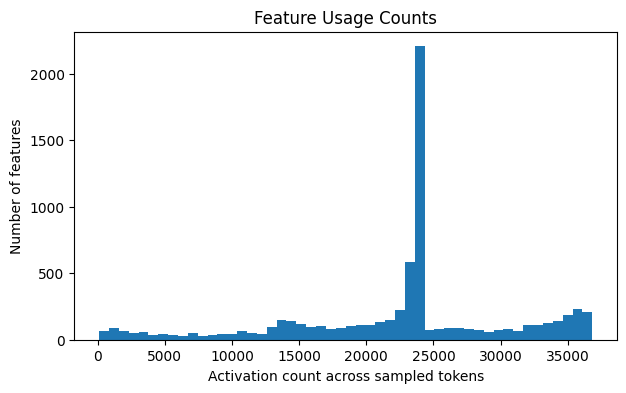

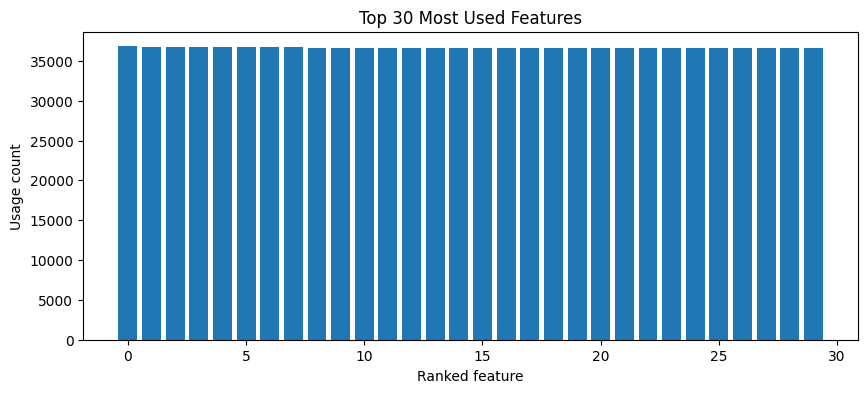

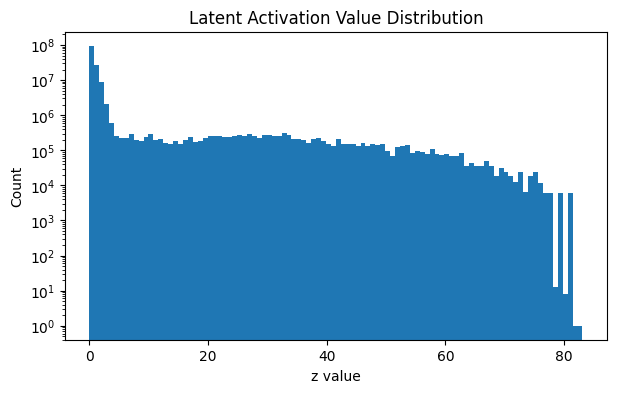

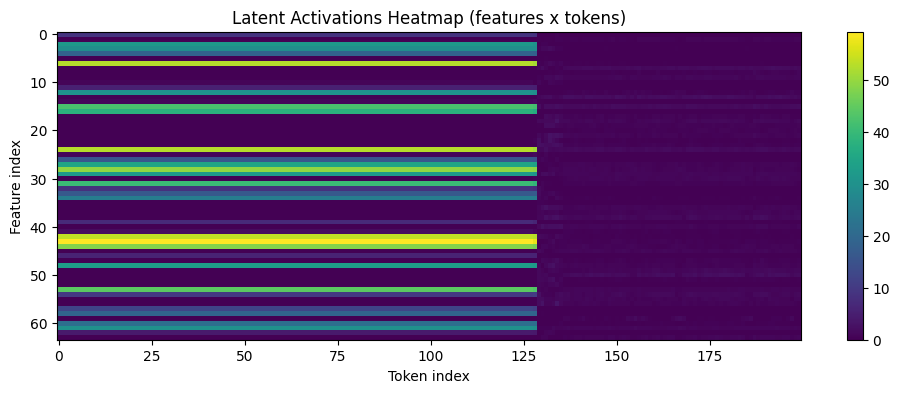

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [ ]:
# -------------------------
# 3) Visualizations
# -------------------------
usage = metrics["usage_counter"]
z_sample = metrics["z_sample"]

# Feature usage histogram
plt.figure(figsize=(7,4))
plt.hist(usage, bins=50)
plt.title("Feature Usage Counts")
plt.xlabel("Activation count across sampled tokens")
plt.ylabel("Number of features")
plt.show()

# Top most-used features
top_k = 30 # try 100
top_idx = np.argsort(-usage)[:top_k]
plt.figure(figsize=(10,4))
plt.bar(np.arange(top_k), usage[top_idx])
plt.title(f"Top {top_k} Most Used Features")
plt.xlabel("Ranked feature")
plt.ylabel("Usage count")
plt.show()

if z_sample is not None:
    # Latent activation value distribution
    plt.figure(figsize=(7,4))
    plt.hist(z_sample.flatten(), bins=100)
    plt.title("Latent Activation Value Distribution")
    plt.xlabel("z value")
    plt.ylabel("Count")
    plt.yscale("log")
    plt.show()

    # Sequence-position heatmap-like view (first 200 tokens, first 64 features)
    n_tokens = min(200, z_sample.shape[0])
    n_feats = min(64, z_sample.shape[1])
    plt.figure(figsize=(12,4))
    plt.imshow(z_sample[:n_tokens, :n_feats].T, aspect="auto", interpolation="nearest")
    plt.title("Latent Activations Heatmap (features x tokens)")
    plt.xlabel("Token index")
    plt.ylabel("Feature index")
    plt.colorbar()
    plt.show()

    # Optional UMAP projection of token latents
    if HAS_UMAP and z_sample.shape[0] > 200:
        z_for_umap = z_sample[:5000]
        reducer = umap.UMAP(n_neighbors=30, min_dist=0.05, metric="cosine", random_state=42)
        z_2d = reducer.fit_transform(z_for_umap)

        plt.figure(figsize=(6,6))
        plt.scatter(z_2d[:,0], z_2d[:,1], s=2, alpha=0.5)
        plt.title("UMAP of SAE Latent Activations")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.show()
    elif not HAS_UMAP:
        print("UMAP not installed. `pip install umap-learn` to enable latent-space plot.")

In [ ]:
# -------------------------
# 4) Optional: quick baseline comparison helper for comparing multiple SAEs
# -------------------------
def print_eval_table(rows):
    # rows: list of dicts with keys: name + metric keys
    cols = ["name","mse","explained_variance","avg_active_features_per_token","dead_feature_rate","usage_perplexity"]
    print(" | ".join(f"{c:>28}" for c in cols))
    print("-" * (31 * len(cols)))
    for r in rows:
        vals = []
        for c in cols:
            v = r[c]
            if isinstance(v, float):
                vals.append(f"{v:>28.6f}")
            else:
                vals.append(f"{str(v):>28}")
        print(" | ".join(vals))

# Example:
#rows = []
#for name, sae_model in [("sae_l1_1e-3", sae1), ("sae_l1_5e-4", sae2)]:
#    m = evaluate_sae(sae_model, x_train)
#    m["name"] = name
#    rows.append(m)
#print_eval_table(rows)

NameError: name 'sae1' is not defined